In [ ]:
# Tokenizing sentences into words

sentence = "Hello world, this is a simple example of tokenization."

# Method 1: Using split()
words = sentence.split()    # use spaces to split the sentence
print("Method 1 - split():")
print(words)

# Method 2: Using regex
import re
# \b denotes word boundaries (e.g., space, beginning of a word)
# \w+ matches one or more word characters
words = re.findall(r'\b\w+\b', sentence)
print("\nMethod 2 - regex:")
print(words)

# Method 3: Using NLTK
from nltk.tokenize import word_tokenize
# can keep the punctuations as separate tokens
words = word_tokenize(sentence)
print("\nMethod 3 - NLTK:")
print(words)

Method 1 - split():
['Hello', 'world,', 'this', 'is', 'a', 'simple', 'example', 'of', 'tokenization.']

Method 2 - regex:
['Hello', 'world', 'this', 'is', 'a', 'simple', 'example', 'of', 'tokenization']

Method 3 - NLTK:
['Hello', 'world', ',', 'this', 'is', 'a', 'simple', 'example', 'of', 'tokenization', '.']


In [ ]:
def split_on_delimiters(token):
    # split on hyphens and underscores
    parts = re.split(r'[-_]', token)
    return [p for p in parts if p]

def split_camel_case(token):
    # insert space before capital letters
    s = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', token)
    return s.split()

def split_alphanum(token):
    # split into alphabetic, numeric, and punctuation parts
    return re.findall(r'[A-Za-z]+|\d+|[^\w\s]', token)

def subword_tokenize(token):
    # keep punctuation as-is
    if re.match(r'^\W+$', token):   # only non-word characters
        return [token]
    parts = []
    for p in split_on_delimiters(token): # handling snake_case_example
        for q in split_camel_case(p):   # handling camelCaseWord & userID42
            parts.extend(split_alphanum(q)) # handling userID42
    return parts

# Use existing `words` and `sentence` variables from the notebook
subwords = {w: subword_tokenize(w) for w in words}

# Examples with common composite words
composite_examples = [
    'state-of-the-art', 'camelCaseWord', 'snake_case_example',
    'COVID19', 'anti-inflammatory', 'mother-in-law', 'e-mail', 'userID42'
]

# Print results
print("From existing 'words':")
for w, s in subwords.items():
    print(f"{w!r} -> {s}")

print("\nComposite examples:")
for w in composite_examples:
    print(f"{w!r} -> {subword_tokenize(w)}")

From existing 'words':
'Hello' -> ['Hello']
'world' -> ['world']
',' -> [',']
'this' -> ['this']
'is' -> ['is']
'a' -> ['a']
'simple' -> ['simple']
'example' -> ['example']
'of' -> ['of']
'tokenization' -> ['tokenization']
'.' -> ['.']

Composite examples:
'state-of-the-art' -> ['state', 'of', 'the', 'art']
'camelCaseWord' -> ['camel', 'Case', 'Word']
'snake_case_example' -> ['snake', 'case', 'example']
'COVID19' -> ['COVID', '19']
'anti-inflammatory' -> ['anti', 'inflammatory']
'mother-in-law' -> ['mother', 'in', 'law']
'e-mail' -> ['e', 'mail']
'userID42' -> ['user', 'ID', '42']


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA

# =============================================================================
# 1. CREATE TOY CORPUS
# =============================================================================

corpus = [
    "the king sits on the throne",
    "the queen sits beside the king",
    "the prince is son of the king",
    "the princess is daughter of the queen",
    "the king and queen rule the kingdom",
    "the prince will become king",
    "the princess will become queen",
    "a man works in the field",
    "a woman works in the home",
    "the boy plays with the girl",
    "the man and woman are married",
    "the boy will become a man",
    "the girl will become a woman",
    "dogs chase cats in the garden",
    "cats climb trees to escape dogs",
    "dogs bark at strangers",
    "cats meow for food",
    "dogs are loyal pets",
    "cats are independent pets",
    "the dog runs fast",
    "the cat sleeps all day",
    "summer is hot and sunny",
    "winter is cold and snowy",
    "spring brings flowers and rain",
    "autumn brings leaves and wind",
    "summer and winter are opposite seasons",
    "spring and autumn are mild seasons",
    "i love summer weather",
    "i hate winter cold",
    "flowers bloom in spring",
]

print("Corpus size:", len(corpus), "sentences")
print("Sample sentences:")
for sent in corpus[:3]:
    print(f"  - {sent}")

Corpus size: 30 sentences
Sample sentences:
  - the king sits on the throne
  - the queen sits beside the king
  - the prince is son of the king


In [6]:
# =============================================================================
# 2. PREPROCESSING AND VOCABULARY CONSTRUCTION
# =============================================================================

def tokenize(text):
    """Simple whitespace tokenizer with lowercasing"""
    return text.lower().split()

# Tokenize all sentences
tokenized_corpus = [tokenize(sentence) for sentence in corpus]
all_words = [word for sentence in tokenized_corpus for word in sentence]

print(f"\nTotal words in corpus: {len(all_words)}")

# Count word frequencies
word_counts = Counter(all_words)
print(f"Unique words: {len(word_counts)}")

# Filter rare words (optional - keep words appearing at least once)
min_count = 1
vocab = {word for word, count in word_counts.items() if count >= min_count}
vocab = sorted(vocab)

# Create word-to-index and index-to-word mappings
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Sample vocabulary: {vocab[:10]}...")


Total words in corpus: 160
Unique words: 76
Vocabulary size: 76
Sample vocabulary: ['a', 'all', 'and', 'are', 'at', 'autumn', 'bark', 'become', 'beside', 'bloom']...


In [7]:
# =============================================================================
# 3. GENERATE SKIP-GRAM TRAINING PAIRS
# =============================================================================

def generate_skipgram_pairs(tokenized_corpus, word2idx, window_size=2):
    """
    Generate (center_word, context_word) pairs for skip-gram training.
    
    For each word in the corpus, we look at words within the window
    on both sides and create training pairs.
    """
    pairs = []
    
    for sentence in tokenized_corpus:
        # Filter words not in vocabulary
        sentence = [word for word in sentence if word in word2idx]
        
        for i, center_word in enumerate(sentence):
            # Define context window boundaries
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            
            for j in range(start, end):
                if i != j:  # Skip the center word itself
                    context_word = sentence[j]
                    pairs.append((word2idx[center_word], word2idx[context_word]))
    
    return pairs

window_size = 2
training_pairs = generate_skipgram_pairs(tokenized_corpus, word2idx, window_size)

print(f"\nGenerated {len(training_pairs)} training pairs")
print("Sample pairs (center -> context):")
for i in range(5):
    center_idx, context_idx = training_pairs[i]
    print(f"  {idx2word[center_idx]} -> {idx2word[context_idx]}")


Generated 460 training pairs
Sample pairs (center -> context):
  the -> king
  the -> sits
  king -> the
  king -> sits
  king -> on


In [8]:


# =============================================================================
# 4. SKIP-GRAM MODEL IMPLEMENTATION
# =============================================================================

class SkipGramModel:
    """
    Skip-gram Word2Vec model with negative sampling.
    
    Architecture:
    - Input: one-hot encoded center word
    - Hidden layer: embedding lookup (no activation)
    - Output: probability distribution over vocabulary
    
    We use negative sampling for efficient training.
    """
    
    def __init__(self, vocab_size, embedding_dim, learning_rate=0.01):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.lr = learning_rate
        
        # Initialize weight matrices with small random values
        # W1: input -> hidden (center word embeddings)
        # W2: hidden -> output (context word embeddings)
        self.W1 = np.random.randn(vocab_size, embedding_dim) * 0.01
        self.W2 = np.random.randn(embedding_dim, vocab_size) * 0.01
        
    def sigmoid(self, x):
        """Numerically stable sigmoid"""
        return np.where(
            x >= 0,
            1 / (1 + np.exp(-x)),
            np.exp(x) / (1 + np.exp(x))
        )
    
    def forward(self, center_idx):
        """
        Forward pass: get hidden representation for center word
        """
        # Embedding lookup (equivalent to one-hot @ W1)
        hidden = self.W1[center_idx]
        return hidden
    
    def train_pair_negative_sampling(self, center_idx, context_idx, negative_samples):
        """
        Train on one (center, context) pair with negative sampling.
        
        Negative sampling approximates the full softmax by only updating
        weights for the true context word and a few random "negative" words.
        """
        # Forward pass
        hidden = self.forward(center_idx)  # shape: (embedding_dim,)
        
        # Positive sample (true context word)
        pos_score = np.dot(hidden, self.W2[:, context_idx])
        pos_pred = self.sigmoid(pos_score)
        pos_error = pos_pred - 1  # target is 1
        
        # Negative samples (random words that are NOT context)
        neg_errors = []
        for neg_idx in negative_samples:
            neg_score = np.dot(hidden, self.W2[:, neg_idx])
            neg_pred = self.sigmoid(neg_score)
            neg_errors.append((neg_idx, neg_pred - 0))  # target is 0
        
        # Compute gradients and update weights
        # Gradient for W2 (context embeddings)
        grad_W2_pos = pos_error * hidden
        self.W2[:, context_idx] -= self.lr * grad_W2_pos
        
        grad_hidden = pos_error * self.W2[:, context_idx].copy()
        
        for neg_idx, neg_error in neg_errors:
            grad_W2_neg = neg_error * hidden
            self.W2[:, neg_idx] -= self.lr * grad_W2_neg
            grad_hidden += neg_error * self.W2[:, neg_idx]
        
        # Gradient for W1 (center word embedding)
        self.W1[center_idx] -= self.lr * grad_hidden
        
        # Return loss for monitoring
        loss = -np.log(self.sigmoid(pos_score) + 1e-10)
        for neg_idx, _ in neg_errors:
            neg_score = np.dot(self.forward(center_idx), self.W2[:, neg_idx])
            loss -= np.log(self.sigmoid(-neg_score) + 1e-10)
        
        return loss
    
    def get_embeddings(self):
        """Return the learned word embeddings (from W1)"""
        return self.W1.copy()

In [9]:
# =============================================================================
# 5. TRAINING THE MODEL
# =============================================================================

# Hyperparameters
embedding_dim = 50
learning_rate = 0.025
num_epochs = 100
num_negative_samples = 5

# Create noise distribution for negative sampling (based on word frequency)
word_freqs = np.array([word_counts[idx2word[i]] for i in range(vocab_size)])
noise_dist = np.power(word_freqs, 0.75)  # Raise to 3/4 power (common practice)
noise_dist = noise_dist / noise_dist.sum()

# Initialize model
model = SkipGramModel(vocab_size, embedding_dim, learning_rate)

print(f"\nTraining Skip-gram model...")
print(f"  Embedding dimension: {embedding_dim}")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")
print(f"  Negative samples: {num_negative_samples}")
print()

# Training loop
losses = []
for epoch in range(num_epochs):
    np.random.shuffle(training_pairs)
    epoch_loss = 0
    
    for center_idx, context_idx in training_pairs:
        # Sample negative examples (words that are not the context)
        negative_samples = []
        while len(negative_samples) < num_negative_samples:
            neg = np.random.choice(vocab_size, p=noise_dist)
            if neg != context_idx:
                negative_samples.append(neg)
        
        loss = model.train_pair_negative_sampling(center_idx, context_idx, negative_samples)
        epoch_loss += loss
    
    avg_loss = epoch_loss / len(training_pairs)
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

print("\nTraining complete!")


Training Skip-gram model...
  Embedding dimension: 50
  Learning rate: 0.025
  Epochs: 100
  Negative samples: 5

  Epoch 20/100, Loss: 2.6707
  Epoch 40/100, Loss: 2.0754
  Epoch 60/100, Loss: 1.6112
  Epoch 80/100, Loss: 1.3418
  Epoch 100/100, Loss: 1.2465

Training complete!


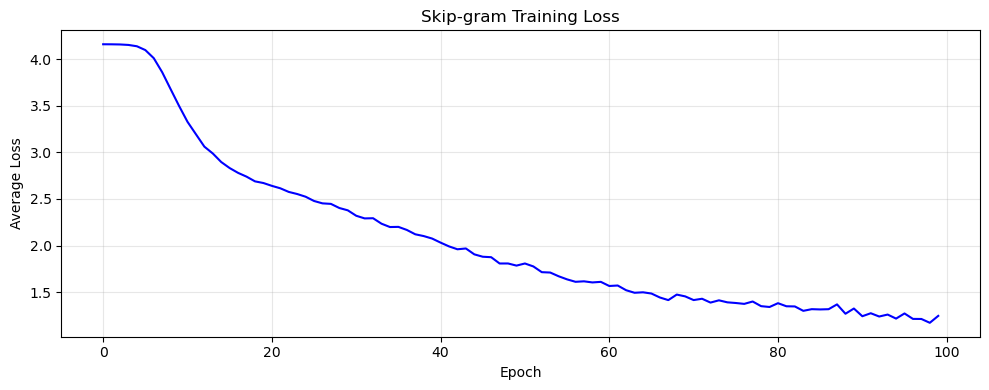


Embedding matrix shape: (76, 50)
Explained variance ratio: [0.25050212 0.14607675]
Total variance explained: 39.66%


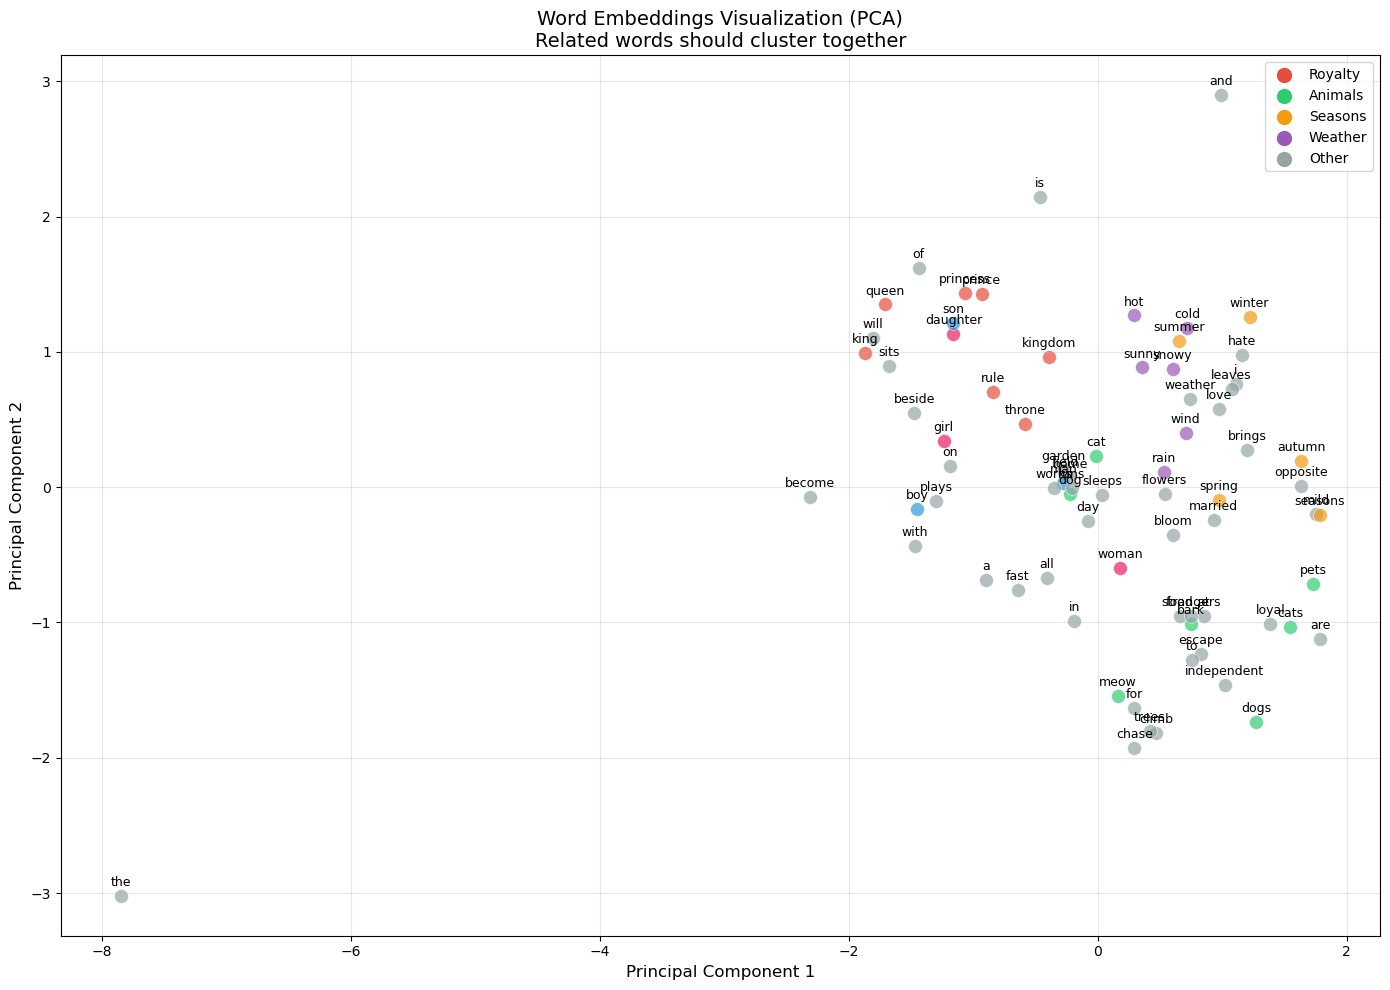

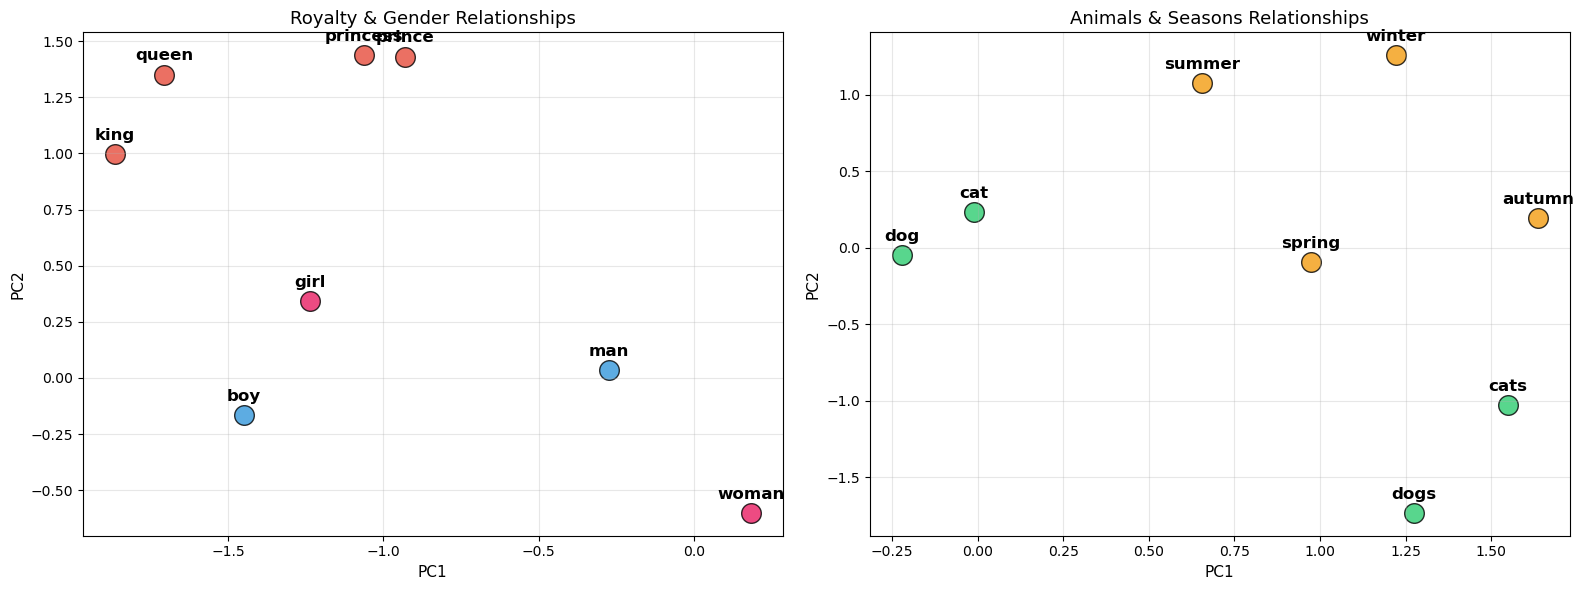


WORD SIMILARITY ANALYSIS

Most similar to 'king':
  queen: 0.8953
  rule: 0.8375
  sits: 0.8326
  throne: 0.8203
  girl: 0.7876

Most similar to 'queen':
  king: 0.8953
  sits: 0.8048
  beside: 0.7996
  kingdom: 0.7981
  on: 0.7707

Most similar to 'man':
  works: 0.8380
  woman: 0.8268
  home: 0.7220
  a: 0.7219
  field: 0.7033

Most similar to 'woman':
  man: 0.8268
  works: 0.7092
  a: 0.7039
  married: 0.6642
  will: 0.5779

Most similar to 'dogs':
  strangers: 0.9249
  trees: 0.8649
  climb: 0.8356
  pets: 0.8084
  independent: 0.7745

Most similar to 'cats':
  food: 0.8390
  to: 0.7375
  escape: 0.7163
  pets: 0.7099
  home: 0.6954

Most similar to 'summer':
  love: 0.8814
  weather: 0.8485
  i: 0.8414
  sunny: 0.8364
  hate: 0.8301

Most similar to 'winter':
  snowy: 0.8392
  hate: 0.8075
  hot: 0.7717
  love: 0.7610
  seasons: 0.7381

WORD ANALOGY TESTS

'king' is to 'queen' as 'man' is to 'works' (similarity: 0.7729)

'king' is to 'prince' as 'queen' is to 'princess' (similar

In [10]:
# =============================================================================
# 6. VISUALIZE TRAINING LOSS
# =============================================================================

plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Skip-gram Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

# =============================================================================
# 7. GET WORD EMBEDDINGS AND REDUCE DIMENSIONALITY WITH PCA
# =============================================================================

embeddings = model.get_embeddings()
print(f"\nEmbedding matrix shape: {embeddings.shape}")

# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# =============================================================================
# 8. VISUALIZE WORD EMBEDDINGS
# =============================================================================

# Define word groups for colored visualization
word_groups = {
    'royalty': ['king', 'queen', 'prince', 'princess', 'throne', 'kingdom', 'rule'],
    'gender_male': ['man', 'boy', 'son', 'king', 'prince'],
    'gender_female': ['woman', 'girl', 'daughter', 'queen', 'princess'],
    'animals': ['dogs', 'cats', 'dog', 'cat', 'pets', 'bark', 'meow'],
    'seasons': ['summer', 'winter', 'spring', 'autumn', 'seasons'],
    'weather': ['hot', 'cold', 'sunny', 'snowy', 'rain', 'wind'],
}

# Create color mapping
colors = {
    'royalty': '#e74c3c',      # red
    'gender_male': '#3498db',   # blue
    'gender_female': '#e91e63', # pink
    'animals': '#2ecc71',       # green
    'seasons': '#f39c12',       # orange
    'weather': '#9b59b6',       # purple
    'other': '#95a5a6',         # gray
}

def get_word_color(word):
    for group, words in word_groups.items():
        if word in words:
            return colors[group], group
    return colors['other'], 'other'

# Plot 1: All words with semantic groups highlighted
plt.figure(figsize=(14, 10))

# Plot each word
for idx, word in idx2word.items():
    x, y = embeddings_2d[idx]
    color, group = get_word_color(word)
    plt.scatter(x, y, c=color, s=100, alpha=0.7, edgecolors='white', linewidth=0.5)
    plt.annotate(word, (x, y), fontsize=9, ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

# Create legend
legend_elements = [plt.scatter([], [], c=colors[group], s=100, label=group.replace('_', ' ').title())
                   for group in ['royalty', 'animals', 'seasons', 'weather', 'other']]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('Word Embeddings Visualization (PCA)\nRelated words should cluster together', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('word_embeddings_all.png', dpi=150)
plt.show()

# Plot 2: Focus on specific semantic relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Royalty and Gender relationships
ax1 = axes[0]
focus_words_1 = ['king', 'queen', 'prince', 'princess', 'man', 'woman', 'boy', 'girl']
for word in focus_words_1:
    if word in word2idx:
        idx = word2idx[word]
        x, y = embeddings_2d[idx]
        color, _ = get_word_color(word)
        ax1.scatter(x, y, c=color, s=200, alpha=0.8, edgecolors='black', linewidth=1)
        ax1.annotate(word, (x, y), fontsize=12, ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points', fontweight='bold')

ax1.set_xlabel('PC1', fontsize=11)
ax1.set_ylabel('PC2', fontsize=11)
ax1.set_title('Royalty & Gender Relationships', fontsize=13)
ax1.grid(True, alpha=0.3)

# Subplot 2: Animals and Seasons
ax2 = axes[1]
focus_words_2 = ['dogs', 'cats', 'dog', 'cat', 'summer', 'winter', 'spring', 'autumn']
for word in focus_words_2:
    if word in word2idx:
        idx = word2idx[word]
        x, y = embeddings_2d[idx]
        color, _ = get_word_color(word)
        ax2.scatter(x, y, c=color, s=200, alpha=0.8, edgecolors='black', linewidth=1)
        ax2.annotate(word, (x, y), fontsize=12, ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points', fontweight='bold')

ax2.set_xlabel('PC1', fontsize=11)
ax2.set_ylabel('PC2', fontsize=11)
ax2.set_title('Animals & Seasons Relationships', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('word_embeddings_focused.png', dpi=150)
plt.show()

# =============================================================================
# 9. ANALYZE WORD SIMILARITIES
# =============================================================================

def cosine_similarity(v1, v2):
    """Compute cosine similarity between two vectors"""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

def most_similar(word, embeddings, word2idx, idx2word, top_n=5):
    """Find the most similar words to a given word"""
    if word not in word2idx:
        return []
    
    word_idx = word2idx[word]
    word_vec = embeddings[word_idx]
    
    similarities = []
    for idx in range(len(idx2word)):
        if idx != word_idx:
            sim = cosine_similarity(word_vec, embeddings[idx])
            similarities.append((idx2word[idx], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

print("\n" + "="*60)
print("WORD SIMILARITY ANALYSIS")
print("="*60)

test_words = ['king', 'queen', 'man', 'woman', 'dogs', 'cats', 'summer', 'winter']
for word in test_words:
    if word in word2idx:
        similar = most_similar(word, embeddings, word2idx, idx2word)
        print(f"\nMost similar to '{word}':")
        for sim_word, score in similar:
            print(f"  {sim_word}: {score:.4f}")

# =============================================================================
# 10. WORD ANALOGY TEST (if vocabulary allows)
# =============================================================================

def analogy(word_a, word_b, word_c, embeddings, word2idx, idx2word):
    """
    Solve analogy: a is to b as c is to ?
    Uses vector arithmetic: vec(b) - vec(a) + vec(c) ≈ vec(?)
    """
    if word_a not in word2idx or word_b not in word2idx or word_c not in word2idx:
        return None
    
    vec_a = embeddings[word2idx[word_a]]
    vec_b = embeddings[word2idx[word_b]]
    vec_c = embeddings[word2idx[word_c]]
    
    # Compute target vector
    target_vec = vec_b - vec_a + vec_c
    
    # Find closest word (excluding input words)
    exclude = {word_a, word_b, word_c}
    best_word = None
    best_sim = -1
    
    for idx in range(len(idx2word)):
        word = idx2word[idx]
        if word not in exclude:
            sim = cosine_similarity(target_vec, embeddings[idx])
            if sim > best_sim:
                best_sim = sim
                best_word = word
    
    return best_word, best_sim

print("\n" + "="*60)
print("WORD ANALOGY TESTS")
print("="*60)

analogies = [
    ('king', 'queen', 'man'),      # king:queen :: man:? (expect: woman)
    ('king', 'prince', 'queen'),   # king:prince :: queen:? (expect: princess)
    ('man', 'boy', 'woman'),       # man:boy :: woman:? (expect: girl)
    ('dogs', 'cats', 'bark'),      # dogs:cats :: bark:? (expect: meow)
    ('summer', 'winter', 'hot'),   # summer:winter :: hot:? (expect: cold)
]

for a, b, c in analogies:
    result = analogy(a, b, c, embeddings, word2idx, idx2word)
    if result:
        word, score = result
        print(f"\n'{a}' is to '{b}' as '{c}' is to '{word}' (similarity: {score:.4f})")

print("\n" + "="*60)
print("VISUALIZATION COMPLETE!")
print("="*60)
print("\nGenerated plots:")
print("  1. training_loss.png - Training loss over epochs")
print("  2. word_embeddings_all.png - All words with semantic grouping")
print("  3. word_embeddings_focused.png - Focused views on specific relationships")